In [1]:
import pandas as pd

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Department': ['Sales', 'HR', 'Sales', 'HR', 'Sales'],
    'Gender': ['F', 'M', 'M', 'M', 'F'],
    'Age': [25, 30, 45, 28, 35],
    'Salary': [3000, 3200, 3400, 3100, 3300]
}

df = pd.DataFrame(data)
df

,Name,Department,Gender,Age,Salary
0,Alice,Sales,F,25,3000
1,Bob,HR,M,30,3200
2,Charlie,Sales,M,45,3400
3,David,HR,M,28,3100
4,Eve,Sales,F,35,3300


### 내장함수란?
- 데이터를 정리하고 요약하며 구조를 변형하기 위한 필수 도구
- 실기 시험에서는 단독 또는 조합 문제로 출제

### 시험에 주로 출제되는 내장함수
#### 1. 고유값 추출
- 해당 열에서 중복을 제거한 고유값 배열을 반환
- `unique()`

In [2]:
df['Department'].unique()

array(['Sales', 'HR'], dtype=object)

#### 2. 빈도 수 계산
- `value_counts()`

In [4]:
df['Department'].value_counts()

Department
Sales    3
HR       2
Name: count, dtype: int64

#### 3. 사용자 정의 함수 적용
- `apply()`
> - `axis=0`: 열 방향 처리 -> 행 단위 적용
> - `axis=1`: 행 방향 처리 -> 열 단위 적용

In [6]:
def classify_age(row):
    if row['Age'] < 30:
        return '청년'
    else:
        return '장년'

df['Age_group'] = df.apply(classify_age, axis = 1)
df

,Name,Department,Gender,Age,Salary,Age_group
0,Alice,Sales,F,25,3000,청년
1,Bob,HR,M,30,3200,장년
2,Charlie,Sales,M,45,3400,장년
3,David,HR,M,28,3100,청년
4,Eve,Sales,F,35,3300,장년


#### 4. Wide -> Long 형태 변환
- `melt()` 
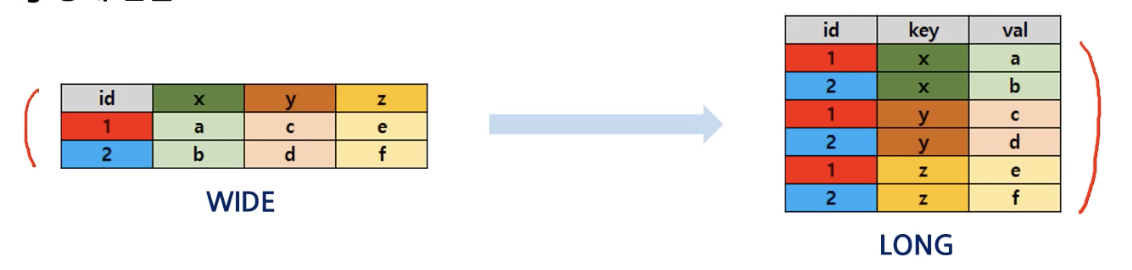

In [7]:
df2 = pd.DataFrame({
    'Name': ['Alice', 'Bob'],
    'Math': [90, 85],
    'English': [88,92],
    'History': [92, 82]
})

df2

,Name,Math,English,History
0,Alice,90,88,92
1,Bob,85,92,82


In [8]:
pd.melt(df2, id_vars='Name', value_vars=['Math', 'English'], 
        var_name='Subject', value_name='Score')

# id_vars : 식별자 변수 / 고정축 (녹이지 않을 컬럼)
# value_vars : 녹일 대상 변수
# var_name : 녹일 컬럼들의 컬럼명
# value_name : 녹일 컬럼들의 실제 값 컬럼명

,Name,Subject,Score
0,Alice,Math,90
1,Bob,Math,85
2,Alice,English,88
3,Bob,English,92
